# [Demo] Escrevendo middlewares

Middleware intercepta pontos fixos do ciclo do agente, sem reescrever esse ciclo. Aqui os hooks entram em
código de verdade.

O que vamos ver:
- `@wrap_tool_call` pra tentar de novo uma tool instável;
- `@wrap_model_call` pra trocar de modelo pela duração da conversa;
- `@dynamic_prompt` pra montar o prompt de sistema a partir do contexto, a versão em middleware do que a
  Aula 3 fez num nó puro;
- estado customizado de middleware, com uma subclasse de `AgentState`.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from collections.abc import Callable
from dataclasses import dataclass
from typing import NotRequired

from IPython.display import Image, display
from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import (
    ModelRequest,
    ModelResponse,
    after_model,
    before_model,
    dynamic_prompt,
    wrap_model_call,
    wrap_tool_call,
)
from langchain.messages import AIMessage, HumanMessage, RemoveMessage, ToolMessage, trim_messages
from langchain.tools import tool
from langchain.tools.tool_node import ToolCallRequest
from langchain_openai import ChatOpenAI
from langgraph.graph.message import REMOVE_ALL_MESSAGES
from langgraph.runtime import Runtime
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

## before_model: cortando o histórico

A Aula 2 já cortou histórico com `trim_messages`, chamado à mão sobre uma lista de mensagens. Um
`before_model` roda a mesma função automaticamente, antes de cada chamada ao modelo, sem precisar lembrar
de chamar o corte a cada turno. Só devolver a lista já cortada não basta: o canal `messages` usa o reducer
`add_messages`, que só sabe acrescentar. Apagar de verdade exige `RemoveMessage(id=REMOVE_ALL_MESSAGES)`
antes das mensagens que devem sobreviver.

In [4]:
@before_model
def trim_history(state: AgentState, runtime: Runtime) -> dict | None:
    trimmed = trim_messages(state["messages"], strategy="last", token_counter=len, max_tokens=4)
    if len(trimmed) == len(state["messages"]):
        return None
    return {"messages": [RemoveMessage(id=REMOVE_ALL_MESSAGES), *trimmed]}

In [5]:
trimming_agent = create_agent(
    model=model,
    tools=[],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial e objetiva.",
    middleware=[trim_history],
)

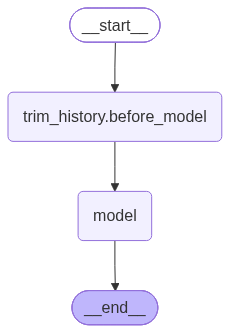

In [6]:
display(Image(trimming_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [7]:
chatty_history = [
    HumanMessage("Quais especialidades vocês atendem?"),
    AIMessage("Atendemos cardiologia, dermatologia e clínica geral."),
    HumanMessage("E o horário de funcionamento?"),
    AIMessage("Das 8h às 18h, de segunda a sexta."),
    HumanMessage("Vocês fazem exame de sangue?"),
]

In [8]:
response = trimming_agent.invoke({"messages": chatty_history})
for message in response["messages"]:
    print(message.type, ":", message.content)

ai : Atendemos cardiologia, dermatologia e clínica geral.
human : E o horário de funcionamento?
ai : Das 8h às 18h, de segunda a sexta.
human : Vocês fazem exame de sangue?
ai : Sim, realizamos exames de sangue na nossa clínica. Se precisar de mais informações sobre os tipos de exames ou agendamento, estamos à disposição!


A primeira pergunta ("Quais especialidades vocês atendem?") não aparece mais no estado final: só as
últimas quatro mensagens do histórico original entraram na chamada, mais a resposta nova. O corte
aconteceu antes do modelo rodar, sem o agente perceber. No grafo acima, `trim_history.before_model`
aparece como um nó próprio, antes de `model`: um hook de nó vira um nó de verdade.

## wrap_tool_call: retry numa tool instável

Uma tool que consulta um sistema externo pode falhar de vez em quando, sem que o agente tenha culpa
nenhuma. `check_lab_results` simula isso: falha nas duas primeiras tentativas e só funciona na terceira.

In [9]:
lab_system_attempts = {"count": 0}

In [10]:
@tool
def check_lab_results(exam_id: str) -> str:
    """Consulta o status de um exame de laboratório da Clínica Alura pelo id."""
    lab_system_attempts["count"] += 1
    if lab_system_attempts["count"] < 3:
        raise RuntimeError("Sistema do laboratório instável, tente novamente.")
    return f"Exame {exam_id}: resultado pronto, sem alterações."

In [12]:
@wrap_tool_call
def retry_tool_call(request: ToolCallRequest, handler: Callable) -> ToolMessage:
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise
            print(f"Tentativa {attempt + 1}/3 falhou: {e}")

In [13]:
lab_agent = create_agent(
    model=model,
    tools=[check_lab_results],
    system_prompt="Você é o assistente da Clínica Alura. Consulte exames quando pedido.",
    middleware=[retry_tool_call],
)

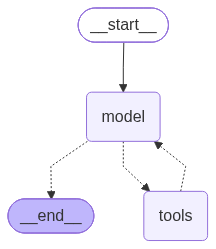

In [14]:
display(Image(lab_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [15]:
response = lab_agent.invoke({"messages": [HumanMessage("Meu exame E123 já saiu?")]})
print(response["messages"][-1].content)

Tentativa 1/3 falhou: Sistema do laboratório instável, tente novamente.
Tentativa 2/3 falhou: Sistema do laboratório instável, tente novamente.
O resultado do seu exame E123 já saiu e está pronto. Não foram detectadas alterações.


A tool falhou duas vezes e a resposta final chegou normal: o retry aconteceu por dentro do
`wrap_tool_call`, sem o modelo nunca ver o erro. No grafo acima, `retry_tool_call` não aparece como nó
separado: um hook de envolvimento continua por dentro do nó `tools`, sem mudar a estrutura visível.

## wrap_model_call: troca de modelo pela duração da conversa

Uma conversa curta não precisa do modelo mais caro. `wrap_model_call` decide, a cada chamada, qual modelo
usar, olhando pro tamanho do histórico que já está no estado. Essa demonstração é a única exceção do curso
ao padrão de usar só `gpt-4o-mini`: trocar de modelo exige ter dois modelos pra trocar entre eles.

In [16]:
advanced_model = ChatOpenAI(model="gpt-5.6-terra")

In [18]:
@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler: Callable) -> ModelResponse:
    message_count = len(request.state["messages"])
    selected_model = advanced_model if message_count > 6 else model
    return handler(request.override(model=selected_model))

In [19]:
model_switch_agent = create_agent(
    model=model,
    tools=[],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial e objetiva.",
    middleware=[dynamic_model_selection],
)

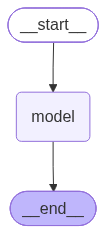

In [20]:
display(Image(model_switch_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [21]:
response_short = model_switch_agent.invoke({"messages": [HumanMessage("Oi, tudo bem?")]})
print(response_short["messages"][-1].response_metadata["model_name"])

gpt-4o-mini-2024-07-18


In [22]:
long_history = [
    HumanMessage("Quais especialidades vocês atendem?"),
    AIMessage("Atendemos cardiologia, dermatologia e clínica geral."),
    HumanMessage("E o horário de funcionamento?"),
    AIMessage("Das 8h às 18h, de segunda a sexta."),
    HumanMessage("Vocês fazem exame de sangue?"),
    AIMessage("Sim, com pedido médico."),
    HumanMessage("E qual o preço da consulta de cardiologia?"),
]

In [23]:
response_long = model_switch_agent.invoke({"messages": long_history})
print(response_long["messages"][-1].response_metadata["model_name"])

gpt-5.6-terra


In [24]:
response_long["messages"][-1].response_metadata

{'token_usage': {'completion_tokens': 62,
  'prompt_tokens': 122,
  'total_tokens': 184,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 25,
   'rejected_prediction_tokens': 0,
   'text_tokens': None},
  'prompt_tokens_details': {'audio_tokens': 0,
   'cache_write_tokens': 0,
   'cached_tokens': 0,
   'image_tokens': None,
   'text_tokens': None}},
 'model_provider': 'openai',
 'model_name': 'gpt-5.6-terra',
 'system_fingerprint': None,
 'id': 'chatcmpl-EK5vsVA7cSby2wzleLqSq4R3rE9Tx',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

Com poucas mensagens, o modelo usado foi `gpt-4o-mini`; passando de seis, virou `gpt-5.6-terra`. A troca
acontece por dentro do `wrap_model_call`, sem o código que chama o agente saber ou se importar com isso.
Mesmo padrão do retry: no grafo acima, só `model` aparece, o hook de envolvimento não vira nó.

## dynamic_prompt: prompt de sistema pelo contexto

A Aula 3 resolveu prompt de sistema mudando por unidade direto no código de um nó puro, sem middleware
(porque middleware ainda não existia até aqui). Com `create_agent`, o mesmo problema tem uma versão em
middleware: `@dynamic_prompt` monta o system prompt a cada chamada, a partir do `runtime.context`.

In [25]:
@dataclass
class ClinicContext:
    unit: str

In [26]:
@dynamic_prompt
def clinic_prompt(request: ModelRequest) -> str:
    unit = request.runtime.context.unit
    return f"Você é o assistente da Clínica Alura, unidade {unit}. Responda de forma cordial e objetiva."

In [27]:
prompt_agent = create_agent(
    model=model,
    tools=[],
    middleware=[clinic_prompt],
    context_schema=ClinicContext,
)

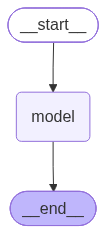

In [28]:
display(Image(prompt_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [29]:
response = prompt_agent.invoke(
    {"messages": [HumanMessage("Com qual unidade da clínica estou falando?")]},
    context=ClinicContext(unit="Zona Sul"),
)
print(response["messages"][-1].content)

Você está falando com a Clínica Alura, unidade Zona Sul. Como posso ajudá-lo hoje?


Mesmo resultado da Aula 3, só que sem um nó de `StateGraph` escrito à mão: `create_agent` mais um
`@dynamic_prompt` bastam quando o agente inteiro é a peça que precisa mudar de prompt. `dynamic_prompt`
por baixo também é um hook de envolvimento: some do grafo pela mesma razão do `wrap_model_call`.

## Estado customizado de middleware

Um middleware pode guardar informação própria no estado do agente, além de `messages`. Uma subclasse de
`AgentState` declara o campo novo; o hook lê e escreve nele como em qualquer outro campo de estado.

In [30]:
class CallCountState(AgentState):
    model_call_count: NotRequired[int]

In [31]:
@after_model(state_schema=CallCountState)
def count_model_calls(state: CallCountState, runtime: Runtime) -> dict | None:
    count = state.get("model_call_count", 0) + 1
    print(f"Chamada ao modelo número {count}")
    return {"model_call_count": count}

In [32]:
@tool
def check_office_hours() -> str:
    """Consulta o horário de funcionamento da Clínica Alura."""
    return "Das 8h às 18h, de segunda a sexta."

In [33]:
counting_agent = create_agent(
    model=model,
    tools=[check_office_hours],
    middleware=[count_model_calls],
)

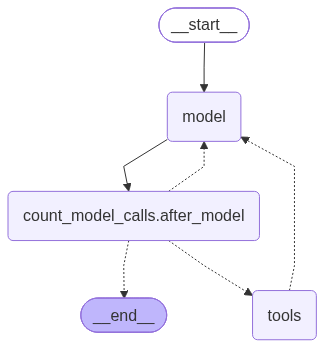

In [34]:
display(Image(counting_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [35]:
response = counting_agent.invoke({"messages": [HumanMessage("Qual o horário de funcionamento da clínica?")]})
print(response["model_call_count"])

Chamada ao modelo número 1
Chamada ao modelo número 2
2


In [36]:
response

{'messages': [HumanMessage(content='Qual o horário de funcionamento da clínica?', additional_kwargs={}, response_metadata={}, id='77022966-5225-489e-b6eb-c2bea04c2b5d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 51, 'total_tokens': 63, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4ce87c02f6', 'id': 'chatcmpl-EK5yceeexURxPDejKoDbBsyPHnlKO', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0686b-0f54-71c0-9988-b888ac8fe727-0', tool_calls=[{'name': 'check_office_hours', 'args': {}, 'id': 'call_JmQSZmxIVaAHrDIjln

O contador chega a 2: um `after_model` depois da primeira resposta, que decide chamar
`check_office_hours`, e outro depois da segunda, que já usa o resultado da tool pra responder.
`model_call_count` chega no resultado final do `invoke`, junto com `messages`: o estado customizado do
middleware faz parte do estado do agente inteiro, não fica escondido dentro do hook, e persiste entre as
duas chamadas ao modelo dessa mesma execução. No grafo acima, `count_model_calls.after_model` aparece como
nó próprio, depois de `model`: outro hook de nó virando nó.

## Takeaway

Middleware tem seis hooks ao todo; aqui escrevemos os quatro mais comuns na prática (`before_model`,
`wrap_tool_call`, `wrap_model_call`, `after_model`), que resolvem problemas genéricos: corte de histórico,
retry, custo, contagem. `before_agent` e `after_agent` ficam só conceituais aqui, pra não inflar o escopo
deste notebook. `dynamic_prompt` reaproveita o mecanismo do `wrap_model_call` por baixo, especializado em
reescrever o prompt de sistema, e por isso também não aparece como nó separado no grafo. Esse mesmo
ferramental serve pra um objetivo mais específico: impedir que o agente vaze dado sensível ou o de outro
paciente.